# Classification de Tumeurs Cérébrales par IRM

Extraction de caractéristiques manuelles (histogramme, texture, contours) + classification KNN.

**Dataset :** Brain Tumor MRI Dataset — 4 classes : `glioma`, `meningioma`, `notumor`, `pituitary`  
**Structure :** `dataset/Training/<classe>/` et `dataset/Testing/<classe>/`

In [11]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
from tqdm import tqdm

## 1. Configuration

In [12]:
IMG_SIZE  = 128
TRAIN_DIR = "./dataset/Training"
TEST_DIR  = "./dataset/Testing"
CLASSES   = ["glioma", "meningioma", "notumor", "pituitary"]
CLASS_IDX = {name: i for i, name in enumerate(CLASSES)}

## 2. Exploration des données

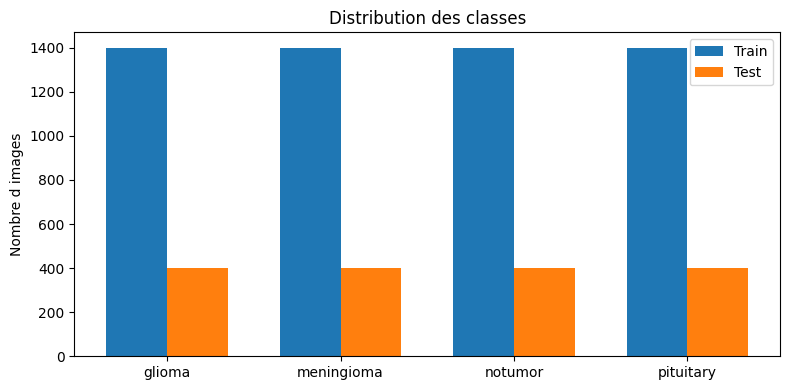

Train: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Test : {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


In [13]:
# Nombre d images par classe
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in CLASSES]

x = np.arange(len(CLASSES))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, train_counts, width, label="Train")
ax.bar(x + width/2, test_counts,  width, label="Test")
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel("Nombre d images"); ax.set_title("Distribution des classes")
ax.legend(); plt.tight_layout(); plt.show()
print("Train:", dict(zip(CLASSES, train_counts)))
print("Test :", dict(zip(CLASSES, test_counts)))

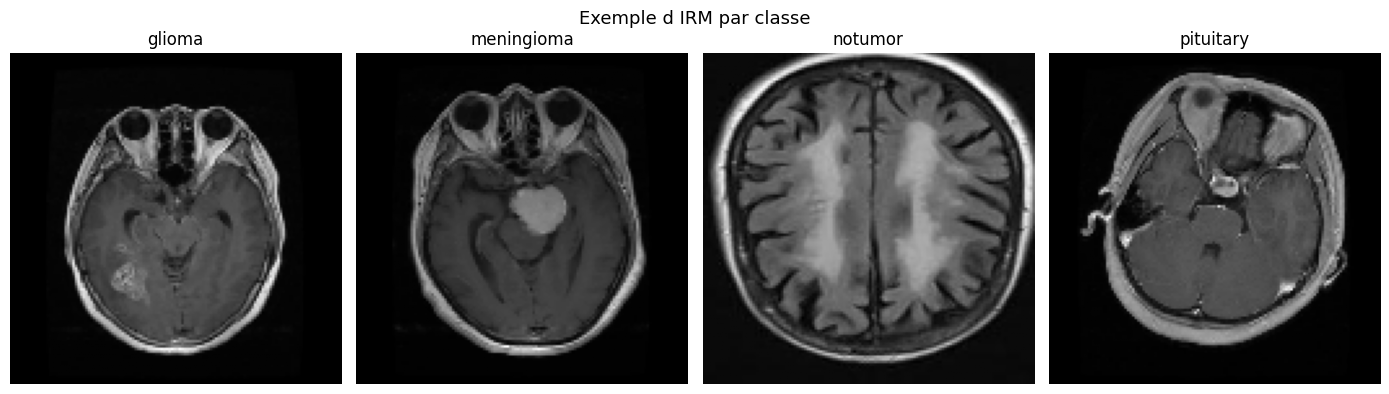

In [14]:
# Exemples d images par classe
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cls in zip(axes, CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    ax.imshow(img, cmap="gray")
    ax.set_title(cls); ax.axis("off")
plt.suptitle("Exemple d IRM par classe", fontsize=13)
plt.tight_layout(); plt.show()

## 3. Extraction de caractéristiques

Chaque image est représentée par un vecteur de **263 caractéristiques** :

| Groupe | Fonction | Taille |
|---|---|---|
| Histogramme |  | 256 |
| Texture |  | 5 |
| Contours (Canny) |  | 2 |

In [15]:
def rgb2gray(I):
    r, g, b = I[:, :, 0], I[:, :, 1], I[:, :, 2]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b


def histo(I):
    h, _ = np.histogram(I.ravel(), bins=256, range=(0, 256))
    return h.astype(np.float64)


def variance2(I):
    return np.var(I)

def energie(I):
    return np.sum(I.astype(np.float64) ** 2) / I.size

def entropie(I):
    h, _ = np.histogram(I.ravel(), bins=256, range=(0, 256))
    p = h / (h.sum() + 1e-10)
    return -np.sum(p * np.log2(p + 1e-10))

def contraste(I):
    return np.mean(np.abs(I[:, 1:].astype(np.float64) - I[:, :-1].astype(np.float64)))

def homogenite(I):
    return 1.0 / (1.0 + np.std(I.astype(np.float64)))

def extract_texture(I):
    return np.array([variance2(I), energie(I), entropie(I),
                     contraste(I), homogenite(I)])


def extract_edges(I):
    edges = cv2.Canny(I.astype(np.uint8), 50, 150)
    return np.array([np.mean(edges), np.std(edges)])


def extract_features(I):
    return np.concatenate([histo(I), extract_texture(I), extract_edges(I)])


print(f"Taille du vecteur de features : {len(extract_features(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)))}")

Taille du vecteur de features : 263


## 4. Chargement des données et extraction des features

In [16]:
def load_dataset(root_dir):
    X, y = [], []
    for cls in CLASSES:
        folder = os.path.join(root_dir, cls)
        label  = CLASS_IDX[cls]
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        for fname in tqdm(files, desc=cls, leave=False):
            path = os.path.join(folder, fname)
            img  = cv2.imread(path)
            if img is None:
                continue
            if img.ndim == 3:
                img = rgb2gray(img)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(extract_features(img))
            y.append(label)
    return np.array(X), np.array(y)


print("Extraction des features (train)...")
X_train, y_train = load_dataset(TRAIN_DIR)
print("Extraction des features (test)...")
X_test,  y_test  = load_dataset(TEST_DIR)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

Extraction des features (train)...


Extraction des features (test)...


X_train : (5600, 263)  |  y_train : (5600,)
X_test  : (1600, 263)   |  y_test  : (1600,)


## 5. Classification KNN

In [17]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean", n_jobs=-1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Modèle KNN entraîné — prédictions sur le jeu de test terminées.")

Modèle KNN entraîné — prédictions sur le jeu de test terminées.


## 6. Évaluation du modèle

In [18]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test, y_pred,    average="macro")
f1   = f1_score(y_test, y_pred,        average="macro")

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASSES))

Accuracy  : 0.7850
Precision : 0.7850
Recall    : 0.7850
F1-score  : 0.7760

              precision    recall  f1-score   support

      glioma       0.79      0.63      0.70       400
  meningioma       0.74      0.59      0.65       400
     notumor       0.74      0.97      0.84       400
   pituitary       0.87      0.95      0.91       400

    accuracy                           0.79      1600
   macro avg       0.78      0.78      0.78      1600
weighted avg       0.78      0.79      0.78      1600



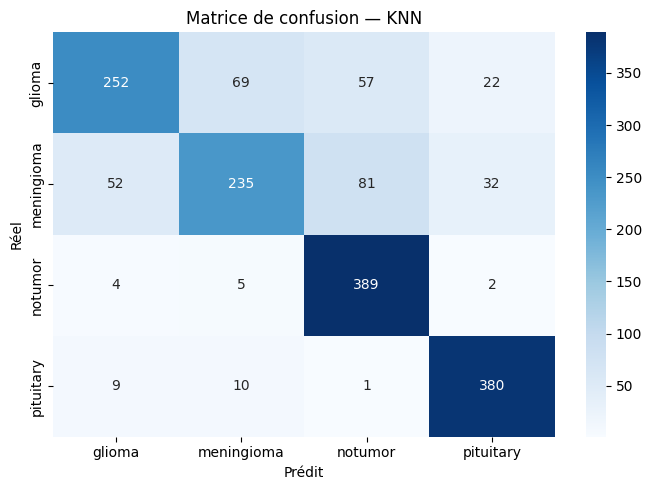

In [19]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — KNN")
plt.tight_layout(); plt.show()

## 7. Analyse des performances

### Résultats obtenus

| Métrique | Valeur |
|---|---|
| **Accuracy** | 78.5 % |
| **Precision** (macro) | 78.5 % |
| **Recall** (macro) | 78.5 % |
| **F1-score** (macro) | 77.6 % |

### Interprétation par classe

| Classe | Précision | Rappel | F1 | Observation |
|---|---|---|---|---|
| **glioma** | 0.79 | 0.63 | 0.70 | 148 images mal classées — souvent confondues avec meningioma (69) et notumor (57) |
| **meningioma** | 0.74 | 0.59 | 0.65 | La classe la plus difficile — 113 erreurs, réparties sur toutes les autres classes |
| **notumor** | 0.74 | 0.97 | 0.84 | Très bon rappel — le modèle détecte presque toujours l'absence de tumeur |
| **pituitary** | 0.87 | 0.95 | 0.91 | Meilleure classe — texture et localisation très caractéristiques |

### Observations clés

- **notumor** et **pituitary** sont excellentes : leurs IRM sont visuellement très distinctes des tumeurs malignes.
- **meningioma** est la plus difficile à classer (F1 = 0.65) car elle ressemble à la fois au glioma et au notumor selon l'IRM.
- **glioma** a un faible rappel (0.63) : 37 % des gliomes ne sont pas détectés — problématique médicalement car c'est la tumeur la plus agressive.

### Limites de l'approche

| Limite | Explication |
|---|---|
| Features globales | L'histogramme et la texture décrivent l'image entière, pas la région tumorale |
| KNN lent à l'inférence | Compare chaque image de test aux 5 600 images d'entraînement |
| Pas invariant à la rotation | Une IRM tournée produit un vecteur de features différent |

### Pistes d'amélioration
- Utiliser un **CNN** (ResNet, VGG) pour extraire des features locales automatiquement
- Ajouter une **segmentation** de la zone tumorale avant extraction
- Tester **SVM** ou **Random Forest** qui gèrent mieux les features non normalisées